<a href="https://colab.research.google.com/github/Janeth172/EDP1/blob/main/Janeth_Camcho_Salvador_Networkx.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **LIBRERÍA NETWORKX**



**Tutorial práctico:** Árbol de expansión mínima $\cdot$ ruta más corta $\cdot$ flujo máximo

# **¿De que trata la librería NetworkX?**

**NetworkX** es una biblioteca de Python para representar y analizar **representaciones gráficas y redes**. Una representación gráfica está formado por:

- **Nodos:** representan entidades o puntos de una red.
- **Arcos:** representan conexiones entre nodos.
- **Costos:** valores asociados a una conexión, por ejemplo distancia, costo o tiempo.
- **Capacidades:** límites de flujo que puede soportar un arco.


La elección del tipo de representación gráfica depende del problema:

$$
\begin{array}{|l|l|l|}
\hline
\textbf{Clase} & \textbf{Representación} & \textbf{Uso típico} \\ \hline
\texttt{nx.Graph()} & \text{No dirigido} & \text{Conexiones bidireccionales} \\ \hline
\texttt{nx.DiGraph()} & \text{Dirigido} & \text{Conexiones con sentido} \\ \hline
\texttt{nx.MultiGraph()} & \text{No dirigido con aristas paralelas} & \text{Varias conexiones entre los mismos nodos} \\ \hline
\texttt{nx.MultiDiGraph()} & \text{Dirigido con aristas paralelas} & \text{Varias conexiones con sentido} \\ \hline
\end{array}
$$

En esta actividad usaremos principalmente `Graph` y `DiGraph`.

Para comenzar, se importan las bibliotecas necesarias. `NetworkX` permitirá crear y analizar redes, mientras que `Matplotlib` se utilizará para generar sus representaciones gráficas.


In [5]:
# Importar librerías
import networkx as nx
import matplotlib.pyplot as plt

Se configuran el tamaño de las gráficas, la fuente y opcional paleta de colores que se utilizará.

In [6]:
# AJUSTES VISUALES

# Tamaño de las gráficas
plt.rcParams["figure.figsize"] = (10, 6)

# Tamaño de la fuente
plt.rcParams["font.size"] = 11

# Paleta de colores
ROSA = "#d63384"
ROSA_OSCURO = "#9b1d5a"
ROSA_CLARO = "#f8c4d9"
GRIS = "#777777"


# **Síntaxis**

Antes de resolver los problemas conviene reconocer tres instrucciones que aparecerán varias veces.

```python
G = nx.Graph()
```

Crea un grafo no dirigido. Para una red con dirección se utiliza:

```python
G = nx.DiGraph()
```

Para añadir varias conexiones con peso se puede usar:

```python
G.add_weighted_edges_from([(origen, destino, peso), ...])
```


Funciones que se utilizaran

$$
\begin{array}{|l|l|}
\hline
\textbf{Comando} & \textbf{Función} \\ \hline
\texttt{G.add_node()} & \text{Añade un nodo} \\ \hline
\texttt{G.add_edge()} & \text{Añade una conexión} \\ \hline
\texttt{G.add_weighted_edges_from()} & \text{Añade varias conexiones con peso} \\ \hline
\texttt{G.nodes} & \text{Consulta los nodos} \\ \hline
\texttt{G.edges(data=True)} & \text{Consulta las aristas y sus atributos} \\ \hline
\texttt{nx.draw()} & \text{Dibuja la red} \\ \hline
\texttt{nx.minimum_spanning_tree()} & \text{Calcula un árbol de expansión mínima} \\ \hline
\texttt{nx.shortest_path()} & \text{Obtiene una ruta de costo mínimo} \\ \hline
\texttt{nx.shortest_path_length()} & \text{Calcula el costo de esa ruta} \\ \hline
\texttt{nx.all_shortest_paths()} & \text{Encuentra todas las rutas que empatan como óptimas} \\ \hline
\texttt{nx.maximum_flow()} & \text{Calcula el flujo máximo} \\ \hline
\texttt{nx.minimum_cut()} & \text{Obtiene el corte mínimo asociado} \\ \hline
\end{array}
$$

# **1. Árbol de Expansión Mínima**

Un **árbol de expansión mínima** conecta todos los nodos de una red sin formar ciclos y con el menor costo total posible.

Si la red es $G=(V,E)$, buscamos un conjunto de aristas $T$ tal que:

$$
\min \sum_{(i,j)\in T} w_{ij}
$$

sujeto a que $T$ conecte todos los nodos y tenga exactamente:

$$
|T|=|V|-1.
$$

En esta actividad debemos usar la **versión no dirigida de la red `actividad_1_a`**.

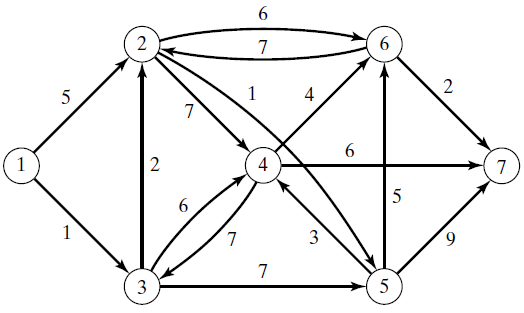

### Conversión de la red

En la imagen existen algunos pares de arcos en sentidos opuestos con pesos distintos. Cuando existen dos pesos entre los mismos nodos, se conserva el **menor peso**, interpretándolo como la alternativa de menor costo para esa conexión.

### Función principal

```python
nx.minimum_spanning_tree(G, weight="weight")
```

Esta función devuelve otro gráfico que contiene únicamente los arcos seleccionados para formar el árbol.


In [8]:
# Crear una red no dirigida a partir de la red original.
G_mst = nx.Graph()

# Definir los arcos de la red junto con sus respectivos pesos
# (nodo_origen, nodo_destino, peso)
aristas_mst = [
    (1, 2, 5),
    (1, 3, 1),
    (2, 3, 2),
    (2, 4, 7),
    (2, 5, 1),
    (2, 6, 6),   # Se conserva el menor peso entre los nodos 2 y 6
    (3, 4, 6),   # Se conserva el menor peso entre los nodos 3 y 4
    (3, 5, 7),
    (4, 5, 3),
    (4, 6, 4),
    (4, 7, 6),
    (5, 6, 5),
    (5, 7, 9),
    (6, 7, 2)
]

# Agregar los arcos y sus pesos a la red.
G_mst.add_weighted_edges_from(aristas_mst)

# Mostrar los nodos de la red en orden ascendente.
print("Nodos:", sorted(G_mst.nodes))

# Mostrar el número total de arcos de la red.
print("Número de arcos:", G_mst.number_of_edges())

Nodos: [1, 2, 3, 4, 5, 6, 7]
Número de arcos: 14


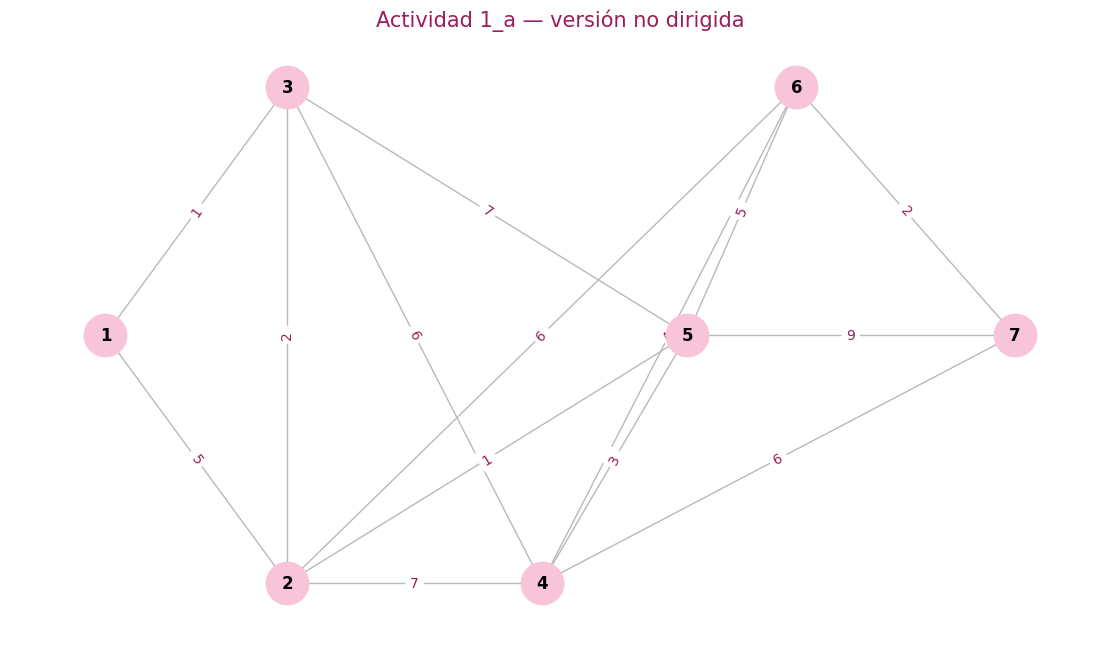

In [9]:
# Visualizar la red no dirigida antes de aplicar el algoritmo.

# Definir la posición de cada nodo en la gráfica
pos_mst = {
    1: (0, 0),
    2: (1, -1.2),
    3: (1, 1.2),
    4: (2.4, -1.2),
    5: (3.2, 0),
    6: (3.8, 1.2),
    7: (5, 0)
}

# Establecer el tamaño de la figura
plt.figure(figsize=(11, 6))

# Dibujar la red con etiquetas, colores y tamaños personalizados
# En este caso rositaa
nx.draw(
    G_mst, pos_mst,
    with_labels=True,
    node_color=ROSA_CLARO,
    node_size=900,
    edge_color="#b9b9b9",
    linewidths=1.5,
    font_weight="bold"
)

# Mostrar los pesos asociados a cada arco
nx.draw_networkx_edge_labels(
    G_mst, pos_mst,
    edge_labels=nx.get_edge_attributes(G_mst, "weight"),
    font_color=ROSA_OSCURO
)

# Agregar el título y ocultar los ejes
plt.title("Actividad 1_a — versión no dirigida", color=ROSA_OSCURO, fontsize=15)
plt.axis("off")

# Mostrar la gráfica
plt.show()


### 1.1 Aplicación de `minimum_spanning_tree`

La función:

```python
T = nx.minimum_spanning_tree(G_mst, weight="weight", algorithm="kruskal")
```
dice que:

- `G_mst` es la red de entrada.
- `weight="weight"` le dice a NetworkX qué atributo contiene los costos.
- `algorithm="kruskal"` solicita el algoritmo de Kruskal.

NetworkX también permite los algoritmos `"prim"` y `"boruvka"`.


In [11]:
# Cálculo del árbol de expansión mínima mediante el algoritmo de Kruskal.
T = nx.minimum_spanning_tree(
    G_mst,
    weight="weight",
    algorithm="kruskal"
)

# Obtener los arcos seleccionados junto con sus respectivos pesos
arcos_T = sorted(T.edges(data="weight"))

# Calcular el costo total del árbol de expansión mínima
costo_T = T.size(weight="weight")

# Mostrar los arcos seleccionadas y sus pesos.
print("Arcos seleccionados:")
for u, v, peso in arcos_T:
    print(f"  {u} — {v}   peso = {peso}")

# Mostrar el costo total y el número de aristas del árbol.
print(f"\nCosto total del árbol = {costo_T:g}")
print(f"Número de arcos = {T.number_of_edges()}")

Arcos seleccionados:
  1 — 3   peso = 1
  2 — 3   peso = 2
  2 — 5   peso = 1
  4 — 5   peso = 3
  4 — 6   peso = 4
  6 — 7   peso = 2

Costo total del árbol = 13
Número de arcos = 6


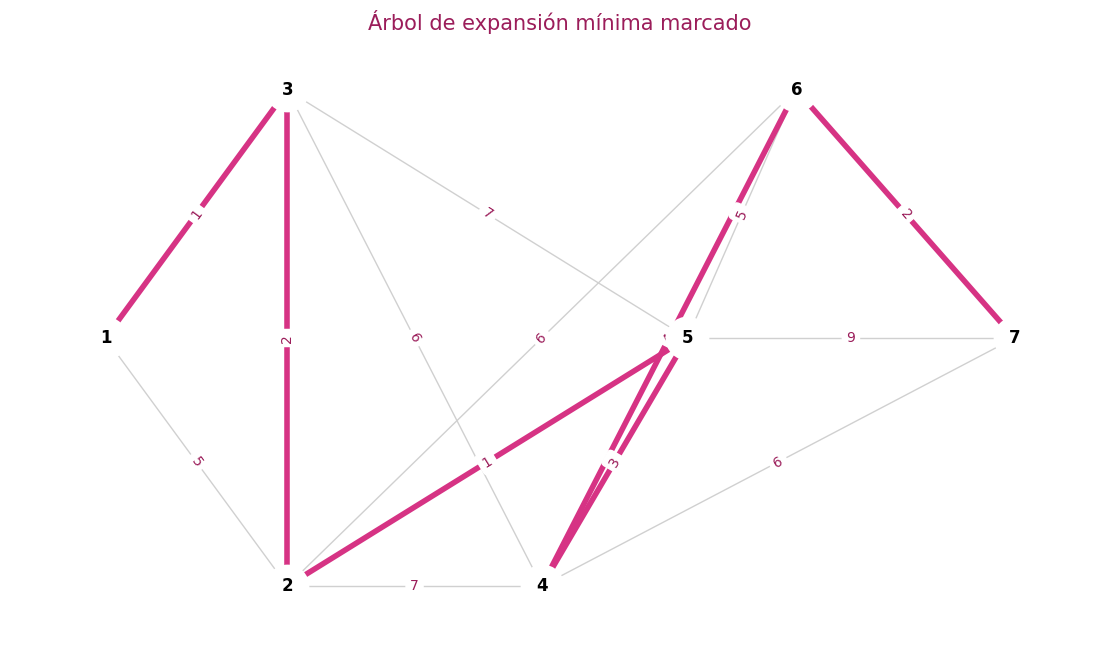

In [13]:
# Verificar que el resultado sea un árbol y que tenga n-1 arcos.
assert nx.is_tree(T)
assert T.number_of_edges() == T.number_of_nodes() - 1

# Dibujar la red completa y resaltar el árbol de expansión mínima
plt.figure(figsize=(11, 6))

# Dibujar la red original
nx.draw(
    G_mst, pos_mst,
    with_labels=True,
    node_color="white",
    node_size=900,
    edge_color="#d0d0d0",
    linewidths=1.5,
    font_weight="bold"
)

# Resaltar los arcos que pertenecen al árbol de expansión mínima.
nx.draw_networkx_edges(
    T, pos_mst,
    edge_color=ROSA,
    width=4
)

# Mostrar los pesos de los arcos de la red
nx.draw_networkx_edge_labels(
    G_mst, pos_mst,
    edge_labels=nx.get_edge_attributes(G_mst, "weight"),
    font_color=ROSA_OSCURO
)

# Agregar el título y mostrar la gráfica.
plt.title("Árbol de expansión mínima marcado", color=ROSA_OSCURO, fontsize=15)
plt.axis("off")
plt.show()

Resultado

Los arcos seleccionados son:

$$
(1,3),\ (2,3),\ (2,5),\ (4,5),\ (4,6),\ (6,7)
$$

y el costo mínimo total es:

$$
13
$$

La comprobación `nx.is_tree(T)` confirma que la solución es un árbol: conecta todos los nodos y no contiene ciclos.



# **2. Ruta más corta**

## 2.1 Formulación

Ahora regresamos a la **red dirigida de `actividad_1_a`**. Queremos encontrar una ruta de un origen $s$ a un destino $t$ minimizando la suma de los pesos de los arcos recorridos.

$$
\min \sum_{(i,j)\in A} c_{ij}x_{ij}
$$

donde $x_{ij}=1$ si el arco pertenece a la ruta y $0$ en caso contrario.

Para esta actividad:

$$
s=1,\qquad t=7
$$

Por lo tanto, buscamos la ruta de **1 a 7**.

### ¿Qué función usar?

```python
nx.shortest_path(G, source=1, target=7, weight="weight")
```

devuelve la secuencia de nodos.

Pero:

```python
nx.shortest_path_length(G, source=1, target=7, weight="weight")
```

devuelve únicamente el costo total.

**NOTA:** si se omite `weight="weight"`, la función puede interpretar que cada arco cuesta 1

In [14]:
# Crear la red dirigida
G_ruta = nx.DiGraph()

# Definir los arcos de la red junto con sus respectivos pesos.
arcos_ruta = [
    (1, 2, 5),
    (1, 3, 1),
    (3, 2, 2),
    (2, 6, 6),
    (6, 2, 7),
    (2, 4, 7),
    (2, 5, 1),
    (3, 4, 6),
    (4, 3, 7),
    (3, 5, 7),
    (5, 4, 3),
    (4, 6, 4),
    (4, 7, 6),
    (5, 6, 5),
    (5, 7, 9),
    (6, 7, 2)
]

# Agregar los arcos ponderados a la red dirigida.
G_ruta.add_weighted_edges_from(arcos_ruta)

# Mostrar los nodos y el número de arcos de la red.
print("Nodos:", sorted(G_ruta.nodes))
print("Arcos:", G_ruta.number_of_edges())

Nodos: [1, 2, 3, 4, 5, 6, 7]
Arcos: 16


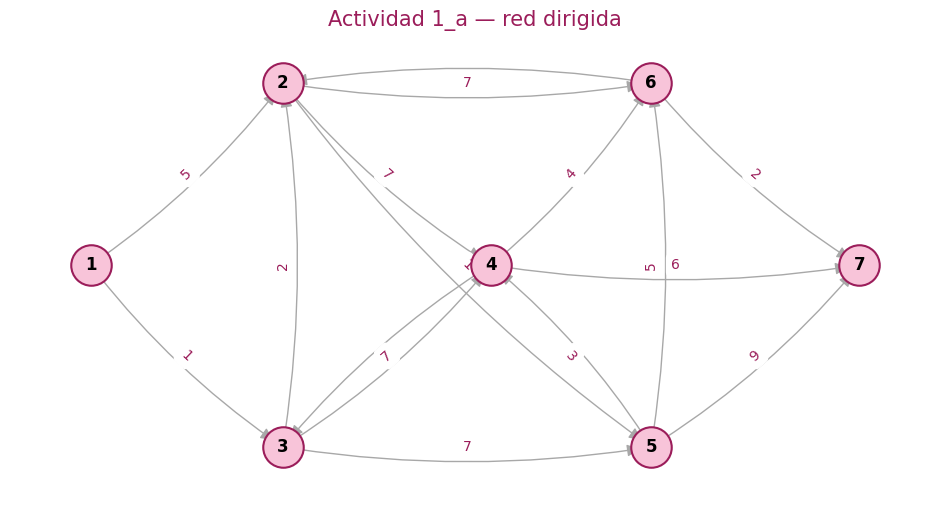

In [15]:
# Definir posiciones fijas
pos_ruta = {
    1: (0, 0),
    2: (1.2, 1.2),
    3: (1.2, -1.2),
    4: (2.5, 0),
    5: (3.5, -1.2),
    6: (3.5, 1.2),
    7: (4.8, 0)
}

# Configurar el tamaño de la figura
plt.figure(figsize=(12, 6))

# Dibujar los nodos de la red
nx.draw_networkx_nodes(
    G_ruta, pos_ruta,
    node_color=ROSA_CLARO,
    node_size=850,
    edgecolors=ROSA_OSCURO,
    linewidths=1.5
)

# Mostrar las etiquetas de los nodos
nx.draw_networkx_labels(G_ruta, pos_ruta, font_weight="bold")

# Dibujar los arcos indicando su dirección mediante flechas
nx.draw_networkx_edges(
    G_ruta, pos_ruta,
    edge_color="#a8a8a8",
    arrows=True,
    arrowsize=18,
    connectionstyle="arc3,rad=0.08"
)

# Mostrar los pesos de los arcos.
nx.draw_networkx_edge_labels(
    G_ruta, pos_ruta,
    edge_labels=nx.get_edge_attributes(G_ruta, "weight"),
    label_pos=0.5,
    font_color=ROSA_OSCURO
)

# Agregar título y mostrar la gráfica.
plt.title("Actividad 1_a — red dirigida", color=ROSA_OSCURO, fontsize=15)
plt.axis("off")
plt.show()

In [16]:
# Definir el nodo de origen y el nodo de destino
origen, destino = 1, 7

# Encontrar la ruta de menor costo entre el origen y el destino
ruta_optima = nx.shortest_path(
    G_ruta,
    source=origen,
    target=destino,
    weight="weight"
)

# Calcular el costo total de la ruta encontrada
distancia_optima = nx.shortest_path_length(
    G_ruta,
    source=origen,
    target=destino,
    weight="weight"
)

# Mostrar la ruta óptima y su costo total
print("Ruta encontrada:", " → ".join(map(str, ruta_optima)))
print("Costo total:", distancia_optima)

Ruta encontrada: 1 → 3 → 2 → 6 → 7
Costo total: 11



### 2.2 ¿Qué pasa con los empates?

No siempre existe una única solución. Por eso es útil `nx.all_shortest_paths()`, que permite detectar empates.

La sintaxis es:

```python
nx.all_shortest_paths(G, source, target, weight="weight")
```

Como devuelve un generador, podemos convertirlo a lista


In [17]:
# Obtener todas las rutas de menor costo
todas_las_optimas = list(
    nx.all_shortest_paths(
        G_ruta,
        source=origen,
        target=destino,
        weight="weight"
    )
)

# Recorrer y mostrar cada una de las rutas óptimas.
for i, camino in enumerate(todas_las_optimas, start=1):

    # Calcular el costo total de cada ruta
    costo = sum(
        G_ruta[u][v]["weight"]
        for u, v in zip(camino, camino[1:])
    )

    # Mostrar la ruta y su costo total.
    print(f"Ruta {i}: {' → '.join(map(str, camino))}   | costo = {costo}")

Ruta 1: 1 → 3 → 2 → 6 → 7   | costo = 11
Ruta 2: 1 → 3 → 2 → 5 → 6 → 7   | costo = 11


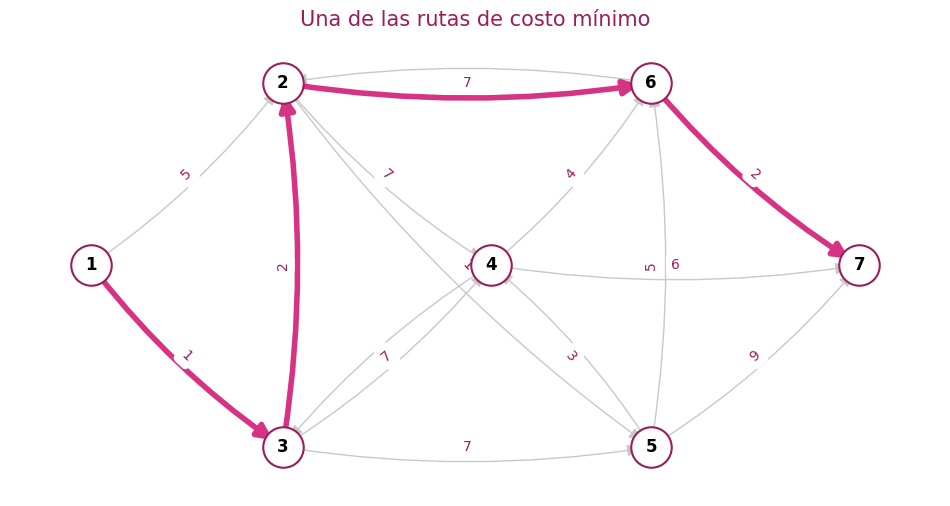

In [18]:
# Resaltar la primera ruta óptima
arcos_optimos = list(zip(ruta_optima, ruta_optima[1:]))

# Configurar el tamaño de la figura
plt.figure(figsize=(12, 6))

# Dibujar los nodos de la red
nx.draw_networkx_nodes(
    G_ruta, pos_ruta,
    node_color="white",
    node_size=850,
    edgecolors=ROSA_OSCURO,
    linewidths=1.5
)

# Mostrar las etiquetas de los nodos
nx.draw_networkx_labels(G_ruta, pos_ruta, font_weight="bold")

# Dibujar todos los arcos
nx.draw_networkx_edges(
    G_ruta, pos_ruta,
    edge_color="#c8c8c8",
    arrows=True,
    arrowsize=18,
    connectionstyle="arc3,rad=0.08"
)

# Resaltar los arcos que forman parte de la ruta óptima.
nx.draw_networkx_edges(
    G_ruta, pos_ruta,
    edgelist=arcos_optimos,
    edge_color=ROSA,
    width=4,
    arrows=True,
    arrowsize=22,
    connectionstyle="arc3,rad=0.08"
)

# Mostrar los pesos de todos los arcos.
nx.draw_networkx_edge_labels(
    G_ruta, pos_ruta,
    edge_labels=nx.get_edge_attributes(G_ruta, "weight"),
    font_color=ROSA_OSCURO
)

# Agregar título y mostrar la gráfica.
plt.title("Una de las rutas de costo mínimo", color=ROSA_OSCURO, fontsize=15)
plt.axis("off")
plt.show()

Resultado de ruta más corta

Se obtienen dos rutas que empatan con costo mínimo:

$$
1 \rightarrow 3 \rightarrow 2 \rightarrow 6 \rightarrow 7
$$

y

$$
1 \rightarrow 3 \rightarrow 2 \rightarrow 5 \rightarrow 6 \rightarrow 7
$$
En ambos casos:

$$
l = 11
$$

Existen **dos rutas óptimas**.


# 3. Flujo máximo

## 3.1 Planteamiento

Para el tercer problema usamos la red dirigida de **`actividad_1_b`**.

Aquí cada arco tiene una **capacidad**, es decir, la cantidad máxima que puede circular por él. Tenemos:

- **fuente:** nodo 1
- **sumidero:** nodo 5

El objetivo es enviar la mayor cantidad posible desde 1 hasta 5.

La formulación puede escribirse como:

$$
\max v
$$

sujeto a conservación de flujo en los nodos intermedios:

$$
\sum_j x_{ij}-\sum_j x_{ji}
=
\begin{cases}
v & i=s\\
-v & i=t\\
0 & \text{en otro caso}
\end{cases}
$$

y a las restricciones de capacidad:

$$
0\leq x_{ij}\leq u_{ij}.
$$


### Funciones principales


$$
\begin{array}{|l|l|}
\hline
\textbf{Función} & \textbf{Resultado} \\
\hline
\texttt{nx.maximum_flow(G, s, t)}
& \text{Valor del flujo y diccionario con los flujos por arco} \\
\hline
\texttt{nx.maximum_flow_value(G, s, t)}
& \text{Solo el valor del flujo máximo} \\
\hline
\texttt{nx.minimum_cut(G, s, t)}
& \text{Capacidad y partición del corte mínimo} \\
\hline
\end{array}
$$


### 3.2 Cálculo del flujo máximo

esto:

```python
valor, flujo = nx.maximum_flow(G_flujo, 1, 5)
```

da dos resultados:

- `valor`: cantidad máxima que puede salir de la fuente y llegar al sumidero.
- `flujo`: diccionario anidado que indica cuánto flujo pasa por cada arco.



In [22]:
# Construcción de la red dirigida
G_flujo = nx.DiGraph()

# Definir los arcos y sus respectivas capacidades.
capacidades = [
    (1, 2, 8),
    (1, 3, 14),
    (1, 5, 4),
    (2, 3, 5),
    (2, 4, 7),
    (2, 5, 6),
    (3, 2, 10),
    (3, 4, 9),
    (3, 5, 10),
    (4, 2, 6),
    (4, 3, 7),
    (4, 5, 5)
]

# Agregar los arcos a la red junto con sus capacidades.
for u, v, capacidad in capacidades:
    G_flujo.add_edge(u, v, capacity=capacidad)

In [24]:
# Definir el nodo fuente y el nodo sumidero
fuente, sumidero = 1, 5

# Calcular el flujo máximo entre la fuente y el sumidero
valor_maximo, flujo = nx.maximum_flow(
    G_flujo,
    fuente,
    sumidero
)

# Mostrar el valor del flujo máximo
print("Flujo máximo =", valor_maximo)
print("\nArcos con flujo positivo:")

# Recorrer los arcos y mostrar aquellos que transportan flujo.
for u in flujo:
    for v, cantidad in flujo[u].items():
        if cantidad > 0:
            capacidad = G_flujo[u][v]["capacity"]
            print(f"  {u} → {v}: {cantidad} de {capacidad}")

Flujo máximo = 25

Arcos con flujo positivo:
  1 → 2: 7 de 8
  1 → 3: 14 de 14
  1 → 5: 4 de 4
  2 → 3: 2 de 5
  2 → 5: 6 de 6
  3 → 4: 6 de 9
  3 → 5: 10 de 10
  4 → 2: 1 de 6
  4 → 5: 5 de 5


In [26]:
# Verificar el resultado
valor_corte, particion = nx.minimum_cut(
    G_flujo,
    fuente,
    sumidero
)

# Separar la partición
S, T_corte = particion

# Mostrar el valor del corte y los nodos que pertenecen a cada conjunto.
print("Valor del corte mínimo:", valor_corte)
print("Conjunto S (lado del origen):", sorted(S))
print("Conjunto T (lado del destino):", sorted(T_corte))

# Comprobar que el flujo máximo coincide con la capacidad del corte mínimo.
assert valor_maximo == valor_corte

Valor del corte mínimo: 25
Conjunto S (lado del origen): [1, 2, 3, 4]
Conjunto T (lado del destino): [5]


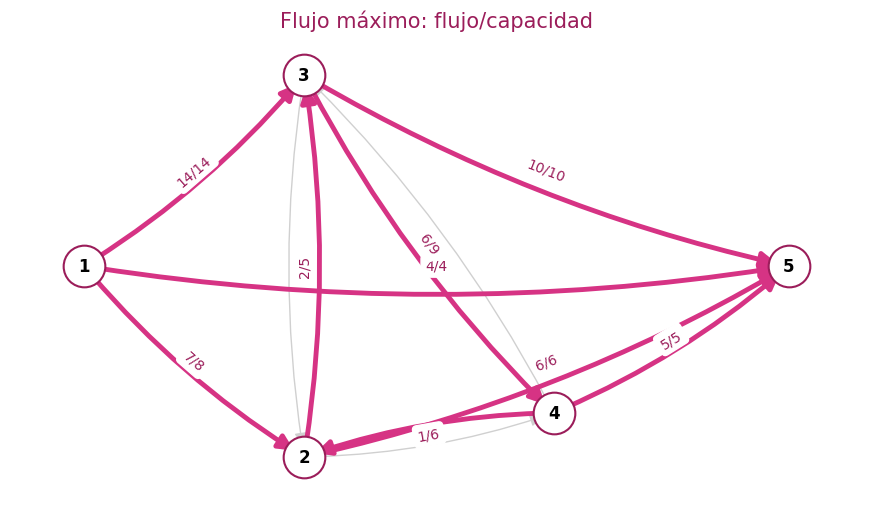

In [29]:
# Visualización final: mostrar el flujo y la capacidad de los arcos con flujo positivo.

pos_flujo = {
    1: (0, 0),
    2: (1.5, -1.3),
    3: (1.5, 1.3),
    4: (3.2, -1.0),
    5: (4.8, 0)
}

# Identificar los arcos
arcos_con_flujo = [
    (u, v)
    for u in flujo
    for v, cantidad in flujo[u].items()
    if cantidad > 0
]

# Crear las etiquetas
etiquetas_flujo = {
    (u, v): f"{flujo[u][v]}/{G_flujo[u][v]['capacity']}"
    for u, v in arcos_con_flujo
}

# Configurar el tamaño de la figura.
plt.figure(figsize=(11, 6))

# Dibujar los nodos de la red.
nx.draw_networkx_nodes(
    G_flujo, pos_flujo,
    node_color="white",
    node_size=900,
    edgecolors=ROSA_OSCURO,
    linewidths=1.5
)

# Mostrar las etiquetas de los nodos.
nx.draw_networkx_labels(G_flujo, pos_flujo, font_weight="bold")

# Dibujar todos los arcos de la red en color grisesito
nx.draw_networkx_edges(
    G_flujo, pos_flujo,
    edge_color="#d0d0d0",
    arrows=True,
    arrowsize=18,
    connectionstyle="arc3,rad=0.08"
)

# Resaltar los arcos que transportan flujo.
nx.draw_networkx_edges(
    G_flujo, pos_flujo,
    edgelist=arcos_con_flujo,
    edge_color=ROSA,
    width=3.5,
    arrows=True,
    arrowsize=22,
    connectionstyle="arc3,rad=0.08"
)

# Mostrar las etiquetas
nx.draw_networkx_edge_labels(
    G_flujo, pos_flujo,
    edge_labels=etiquetas_flujo,
    font_color=ROSA_OSCURO
)

# Agregar título y mostrar la gráfica.
plt.title("Flujo máximo: flujo/capacidad", color=ROSA_OSCURO, fontsize=15)
plt.axis("off")
plt.show()

Resultado de flujo máximo

El flujo máximo desde el nodo 1 hasta el nodo 5 es:

$$
l=25
$$

Una distribución obtenida por NetworkX es:

$$1 \rightarrow 2: 7$$
$$1 \rightarrow 3: 14$$
$$1 \rightarrow 5: 4$$
$$2 \rightarrow 3: 2$$
$$2 \rightarrow 5: 6$$
$$3 \rightarrow 4: 6$$
$$3 \rightarrow 5: 10$$
$$4 \rightarrow 2: 1$$
$$4 \rightarrow 5: 5$$


